# 04 — XAI: LIME vs SHAP pada PRDECT-ID (5-Class Emotion)

Notebook ini menjelaskan prediksi model hybrid IndoBERT + MLP menggunakan:
- **LIME**: Local explanations (per sampel)
- **SHAP**: Local & global explanations
- **Faithfulness Metrics**: Evaluasi kuantitatif terhadap penjelasan XAI

**Label:** Happy (0), Love (1), Anger (2), Fear (3), Sadness (4)

In [1]:
## 0. Google Colab Setup
import sys, os

IN_COLAB = 'google.colab' in sys.modules

if IN_COLAB:
    print('Google Colab detected — mounting Drive & installing packages ...')
    from google.colab import drive
    drive.mount('/content/drive')

    DRIVE_PROJECT = '/content/drive/MyDrive/xai_lime_vs_shap'

    if os.path.isdir(DRIVE_PROJECT):
        os.chdir(DRIVE_PROJECT)
        print(f'CWD set to: {DRIVE_PROJECT}')
    else:
        print(f"WARNING: '{DRIVE_PROJECT}' not found. Please check your Drive path.")

    !pip install -q transformers lime shap datasets accelerate
else:
    print('Local environment — no Colab setup needed.')

Mounted at /content/drive
CWD set to: /content/drive/MyDrive/xai_lime_vs_shap
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 275.7/275.7 kB 9.9 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done


In [2]:
## 1. Imports & Path Setup
import json, warnings, torch, gc
import numpy as np
import pandas as pd
from pathlib import Path
from transformers import AutoTokenizer, AutoModel
from lime.lime_text import LimeTextExplainer
import shap
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import spearmanr

warnings.filterwarnings('ignore')
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
SEED = 42

PROJECT_ROOT  = Path.cwd()
MODEL_DIR     = PROJECT_ROOT / 'outputs' / 'prdect_indobert'
PROC_DIR      = PROJECT_ROOT / 'data' / 'processed'
VIZ_DIR       = MODEL_DIR / 'visualizations'
VIZ_DIR.mkdir(parents=True, exist_ok=True)

print(f'Project root : {PROJECT_ROOT}')
print(f'Device      : {DEVICE}')

Project root : /content/drive/MyDrive/xai_lime_vs_shap
Device      : cuda


In [3]:
## 2. Define MLP & Load Weights
class MLP(torch.nn.Module):
    def __init__(self, input_dim=768, hidden_dim=256, output_dim=5, dropout=0.3):
        super().__init__()
        self.net = torch.nn.Sequential(
            torch.nn.Linear(input_dim, hidden_dim),
            torch.nn.ReLU(),
            torch.nn.Dropout(dropout),
            torch.nn.Linear(hidden_dim, 128),
            torch.nn.ReLU(),
            torch.nn.Dropout(dropout),
            torch.nn.Linear(128, output_dim)
        )

    def forward(self, x):
        return self.net(x)

with open(MODEL_DIR / 'label_map.json') as f:
    label_map = json.load(f)
ID2EMOTION  = {int(k): v for k, v in label_map['id2label'].items()}
CLASS_NAMES = [ID2EMOTION[i] for i in range(len(ID2EMOTION))]
N_CLASSES   = len(CLASS_NAMES)

BERT_MODEL_NAME = 'indobenchmark/indobert-base-p1'
tokenizer  = AutoTokenizer.from_pretrained(BERT_MODEL_NAME)
bert_model = AutoModel.from_pretrained(BERT_MODEL_NAME).to(DEVICE)
bert_model.eval()

classifier = MLP(output_dim=N_CLASSES).to(DEVICE)
classifier.load_state_dict(torch.load(MODEL_DIR / 'mlp_classifier.pt', map_location=DEVICE))
classifier.eval()

print('Models loaded successfully.')

config.json: 0.00B [00:00, ?B/s]

tokenizer_config.json:   0%|          | 0.00/2.00 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

pytorch_model.bin:   0%|          | 0.00/498M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

model.safetensors:   0%|          | 0.00/498M [00:00<?, ?B/s]

Models loaded successfully.


In [4]:
## 3. Define Prediction Wrapper (Robust for SHAP & LIME)
def predict_proba(texts):
    # 1. Konversi ke list jika input adalah numpy array (SHAP sering mengirimkan ini)
    if isinstance(texts, np.ndarray):
        texts = texts.tolist()
    
    # 2. Konversi ke list jika input adalah string tunggal
    if isinstance(texts, str):
        texts = [texts]
        
    # 3. Pastikan semua elemen di dalam list adalah string (SHAP kadang mengirimkan objek)
    texts = [str(t) for t in texts]

    inputs = tokenizer(texts, padding=True, truncation=True, max_length=128, return_tensors='pt').to(DEVICE)
    
    with torch.no_grad():
        outputs = bert_model(**inputs)
        embeddings = outputs.last_hidden_state[:, 0, :]
        logits = classifier(embeddings)
        probs = torch.softmax(logits, dim=-1).cpu().numpy()
    
    return probs

In [5]:
## 4. Load Test Data & Representative Sampling
df_test = pd.read_csv(PROC_DIR / 'prdect_test.csv')

# Filter ulasan kosong agar tidak menyebabkan error pada SHAP
df_test = df_test[df_test['review_clean'].str.strip().str.len() > 0].copy()

def pick_samples(df, label_name):
    sub = df[df['emotion_label'] == label_name].copy()
    texts = sub['review_clean'].astype(str).tolist()
    probs = predict_proba(texts)
    sub['pred_id'] = np.argmax(probs, axis=1)
    sub['confidence'] = np.max(probs, axis=1)
    
    correct = sub[sub['pred_id'] == sub['label']].sort_values('confidence', ascending=False)
    wrong   = sub[sub['pred_id'] != sub['label']].sort_values('confidence', ascending=False)
    
    res = {}
    if len(correct) > 0:
        res['A_correct_high'] = correct.iloc[0]
        if len(correct) > 1:
            res['B_correct_mid'] = correct.iloc[len(correct)//2]
    if len(wrong) > 0:
        res['C_misclassified'] = wrong.iloc[0]
    return res

SAMPLE_SETS = {cls: pick_samples(df_test, cls) for cls in CLASS_NAMES}
all_selected = [SAMPLE_SETS[cls][stype] for cls in SAMPLE_SETS for stype in SAMPLE_SETS[cls]]
samples = pd.DataFrame(all_selected)
print(f'Total samples selected: {len(samples)}')

Total samples selected: 15


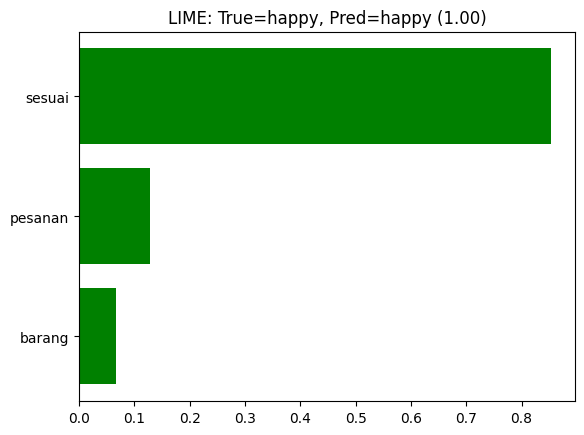

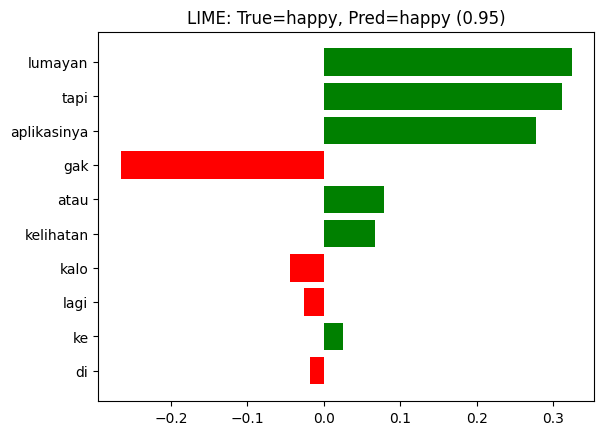

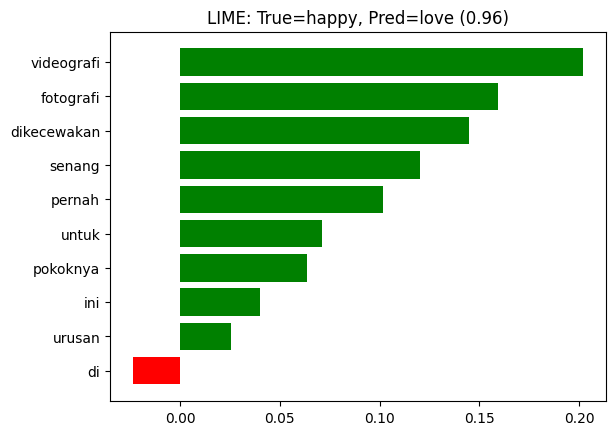

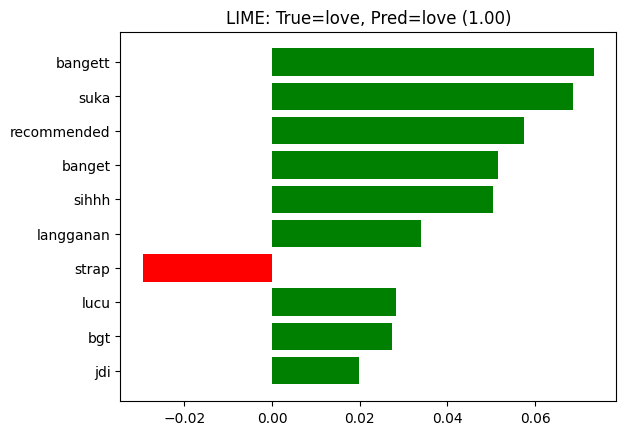

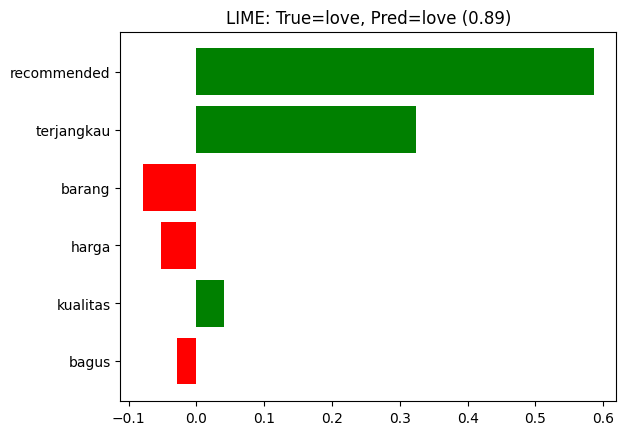

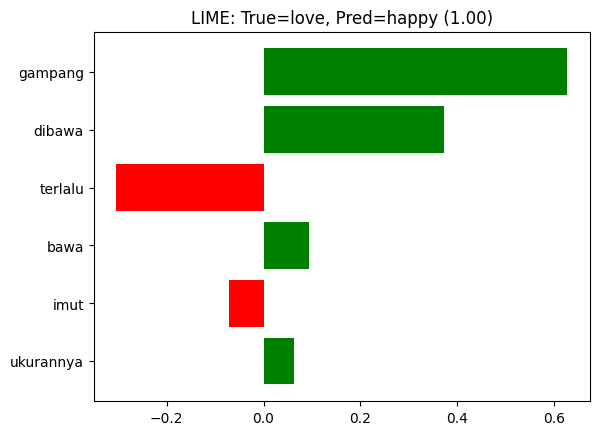

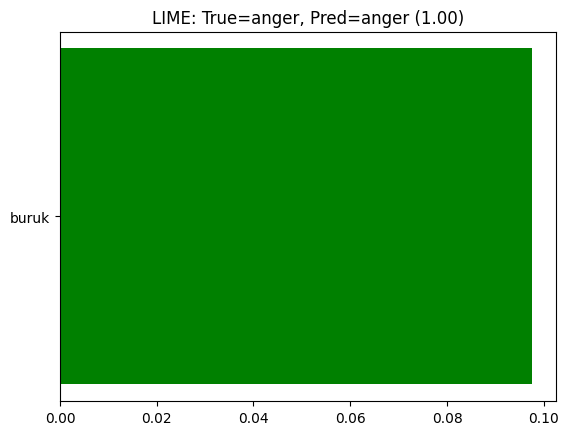

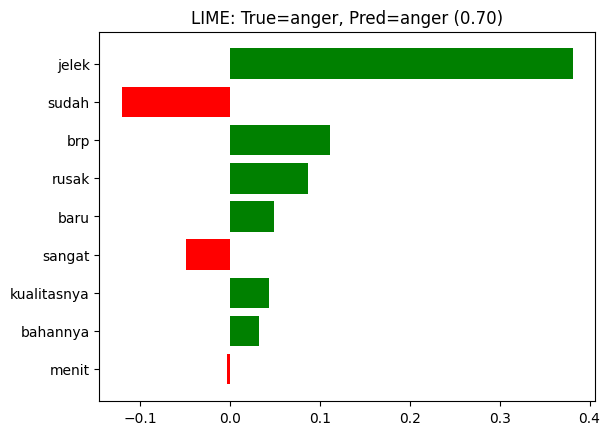

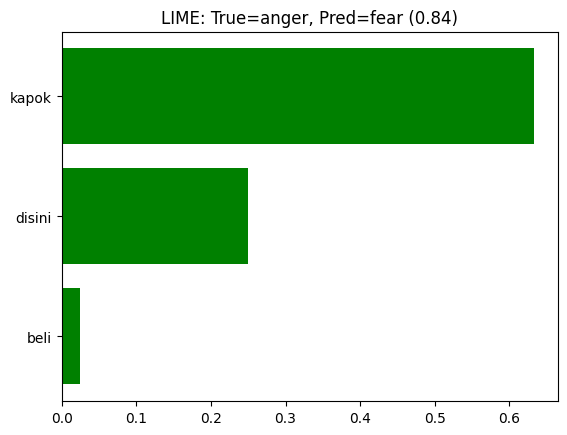

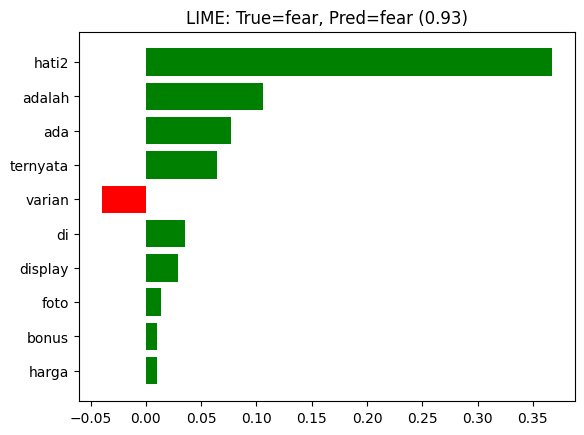

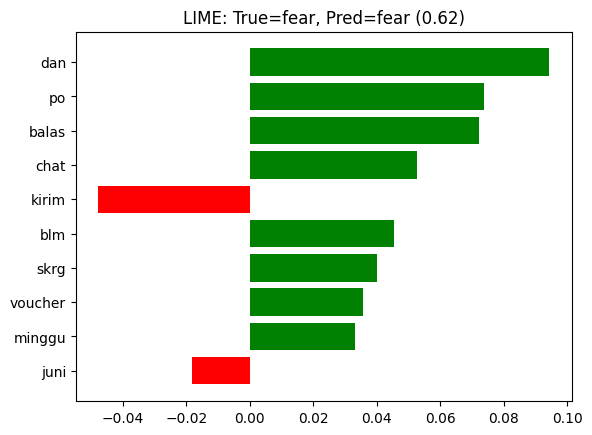

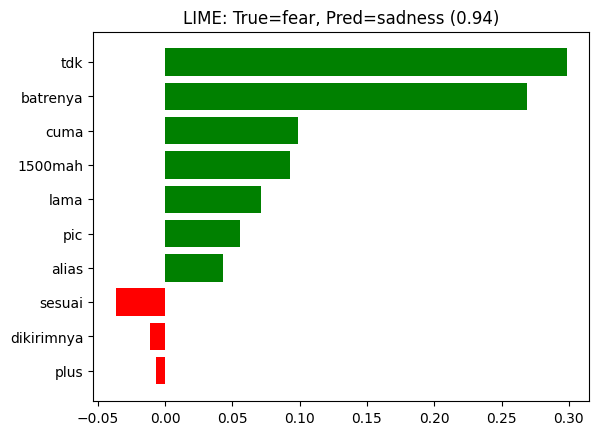

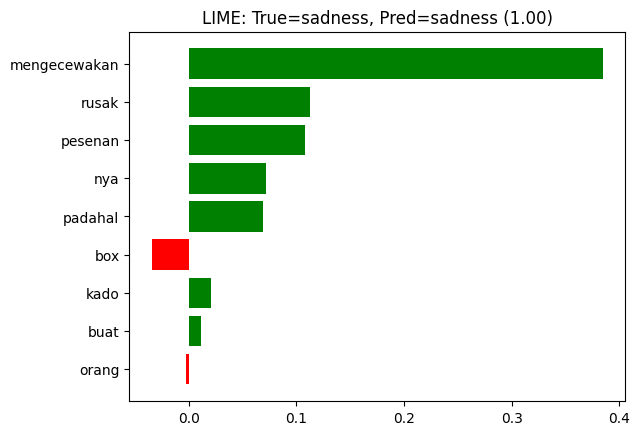

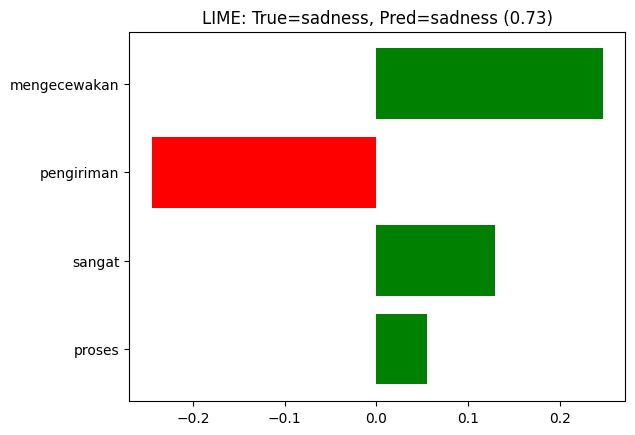

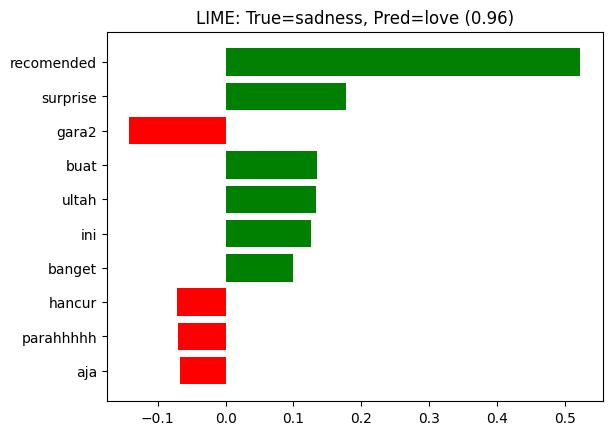

In [6]:
## 5. LIME Explanations
explainer_lime = LimeTextExplainer(class_names=CLASS_NAMES)

for idx, row in samples.iterrows():
    text = str(row['review_clean'])
    # labels=... memastikan LIME menghitung semua probabilitas
    exp = explainer_lime.explain_instance(text, predict_proba, num_features=10, labels=list(range(N_CLASSES)))
    
    probs = predict_proba([text])[0]
    pred_idx = int(np.argmax(probs))
    
    fig = exp.as_pyplot_figure(label=pred_idx)
    plt.title(f'LIME: True={row["emotion_label"]}, Pred={CLASS_NAMES[pred_idx]} ({probs[pred_idx]:.2f})')
    plt.show()


Sample 0: True=happy, Pred=happy


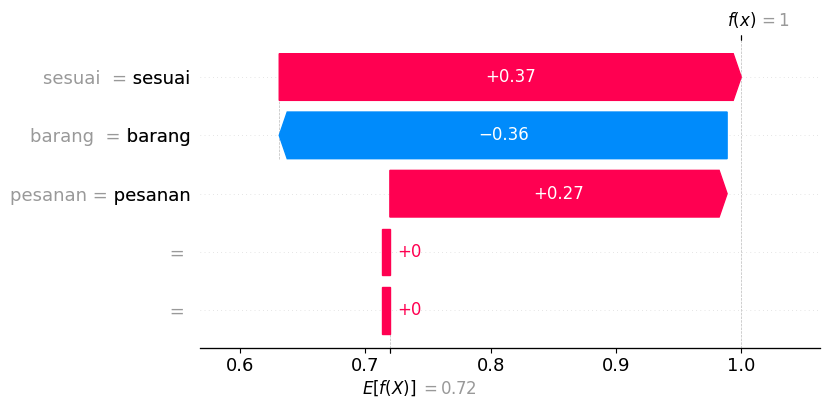


Sample 1: True=happy, Pred=happy


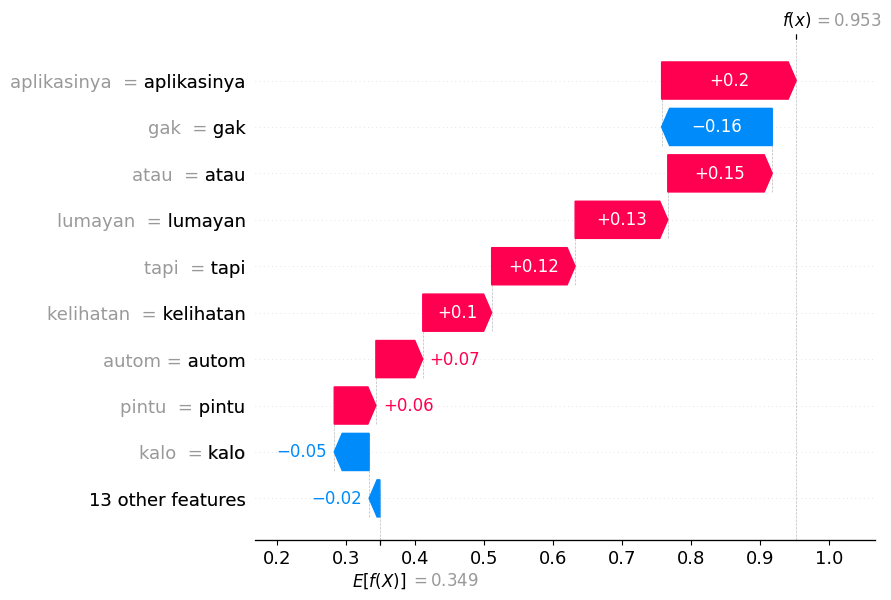


Sample 2: True=happy, Pred=love


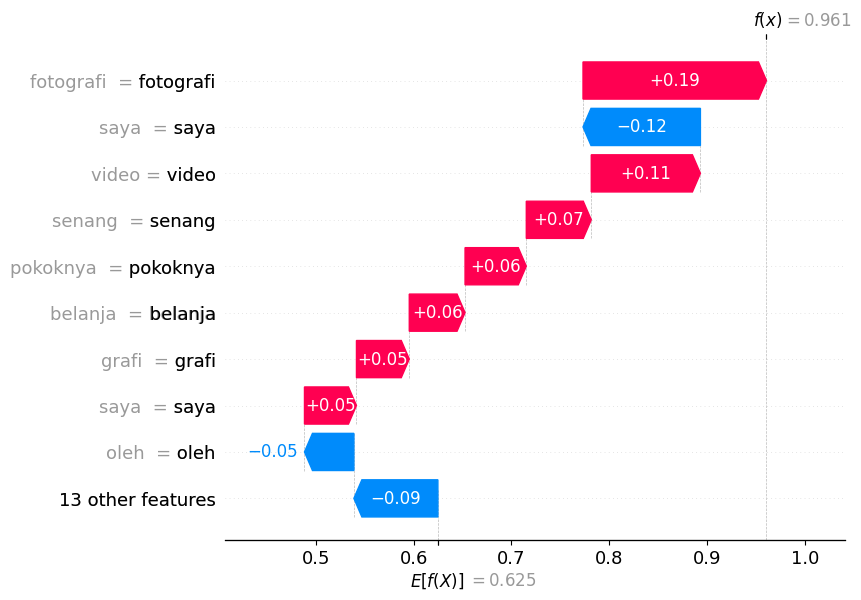


Sample 3: True=love, Pred=love


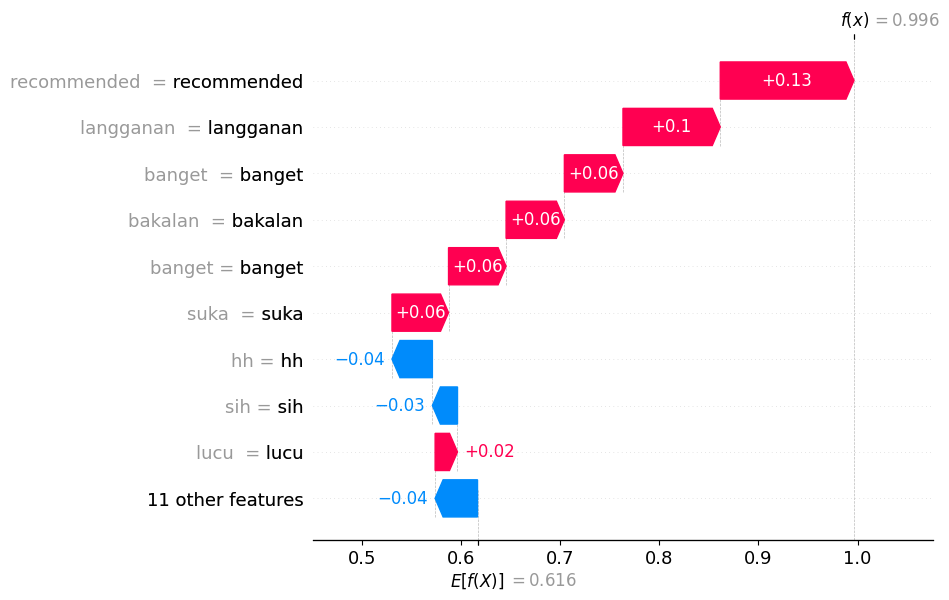


Sample 4: True=love, Pred=love


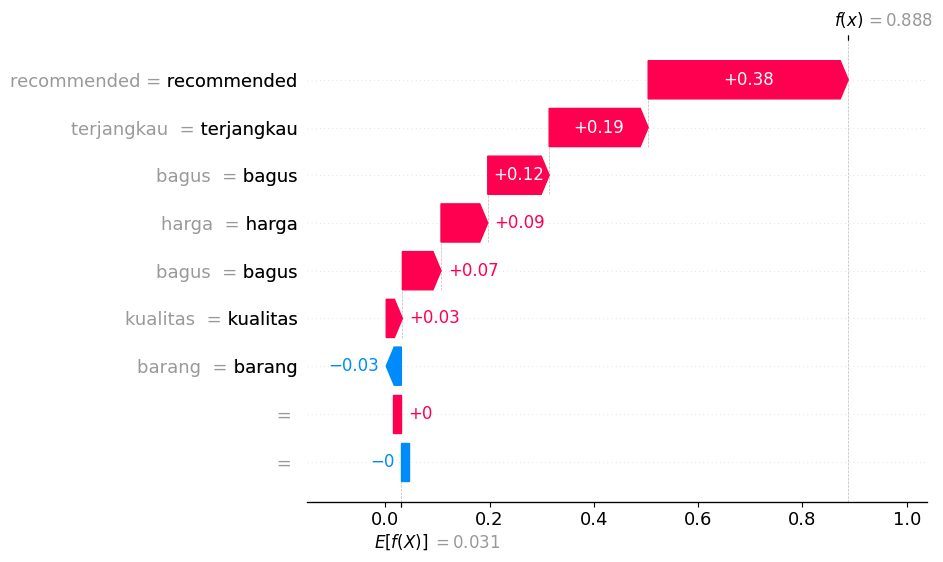


Sample 5: True=love, Pred=happy


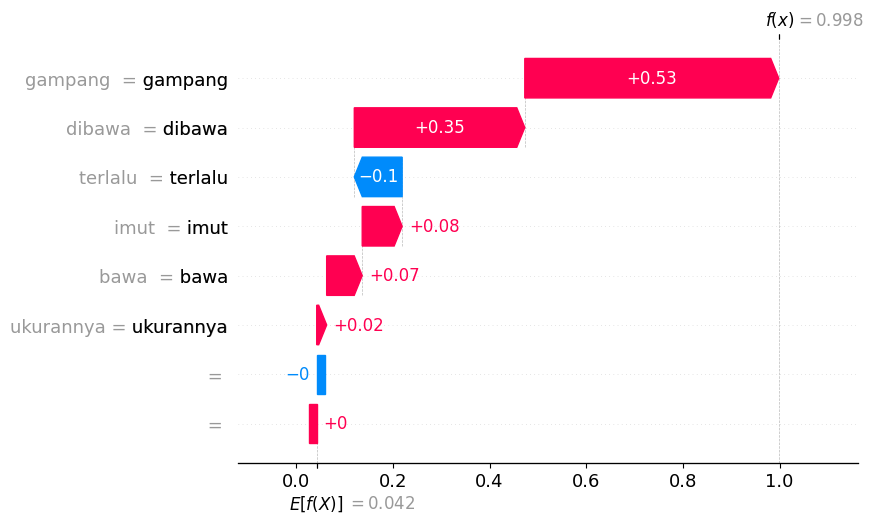


Sample 6: True=anger, Pred=anger


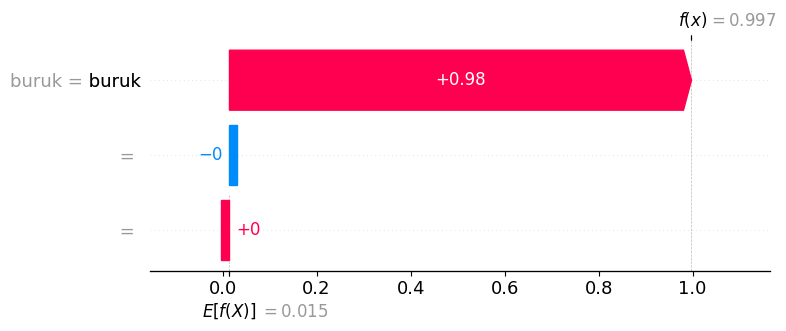


Sample 7: True=anger, Pred=anger


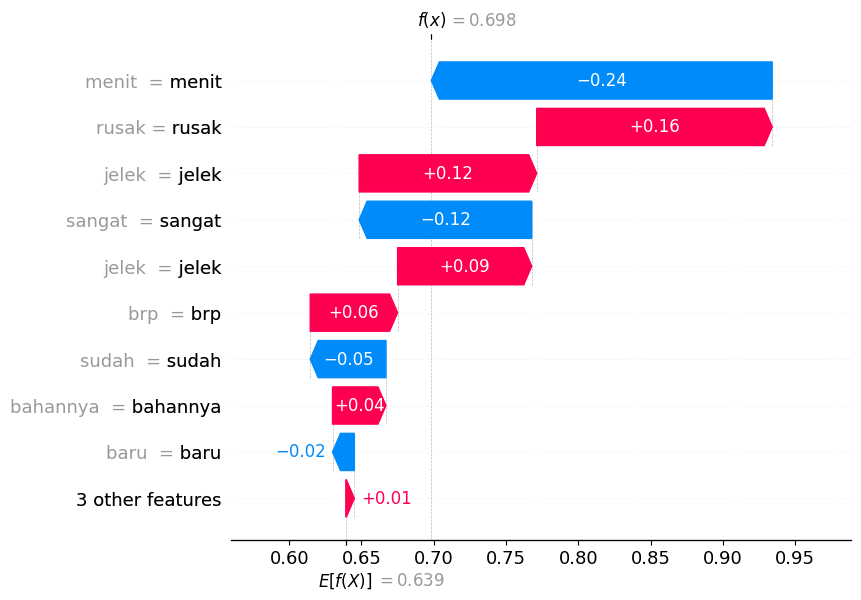


Sample 8: True=anger, Pred=fear


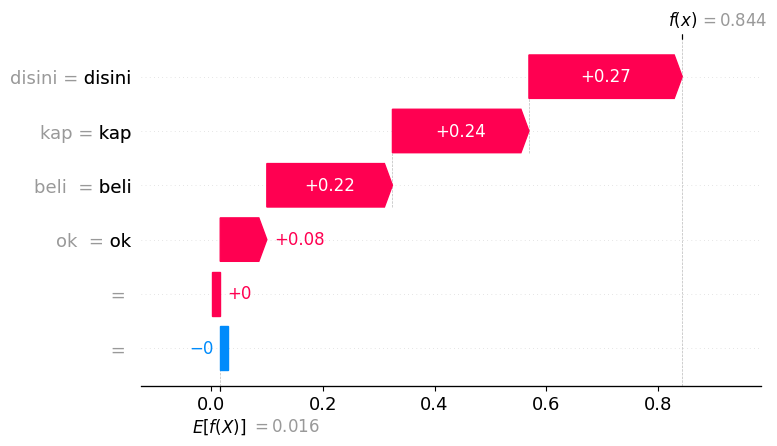


Sample 9: True=fear, Pred=fear


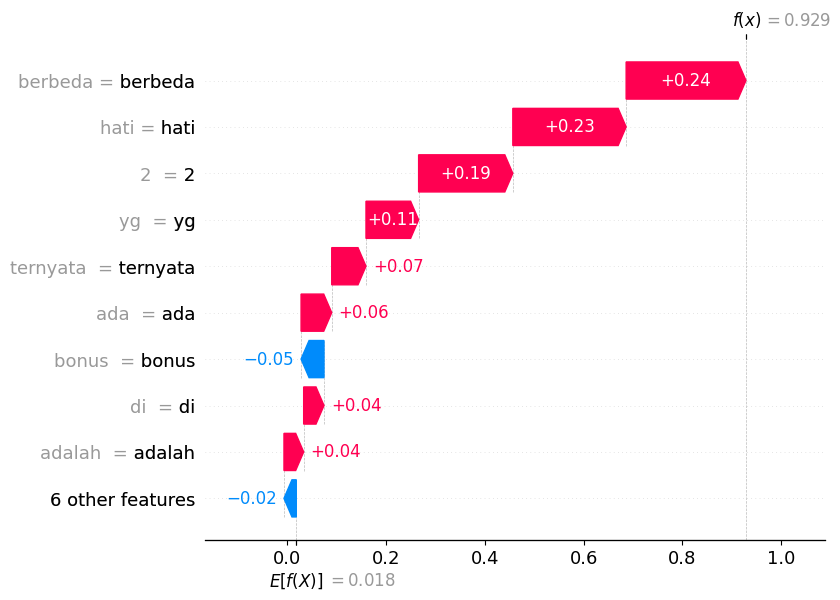


Sample 10: True=fear, Pred=fear


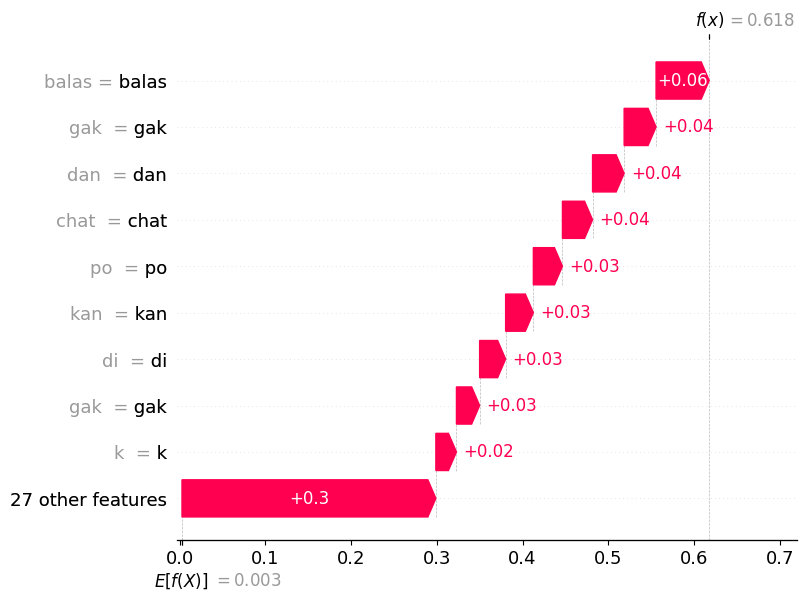


Sample 11: True=fear, Pred=sadness


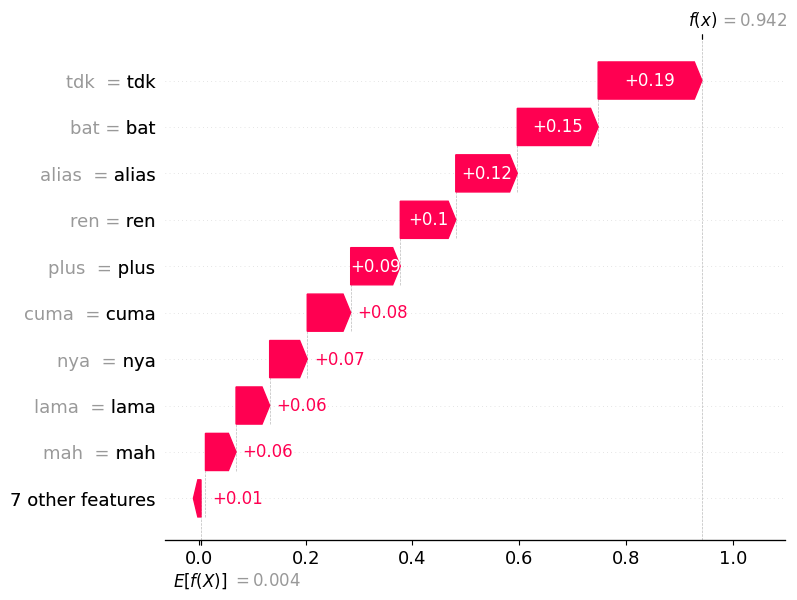


Sample 12: True=sadness, Pred=sadness


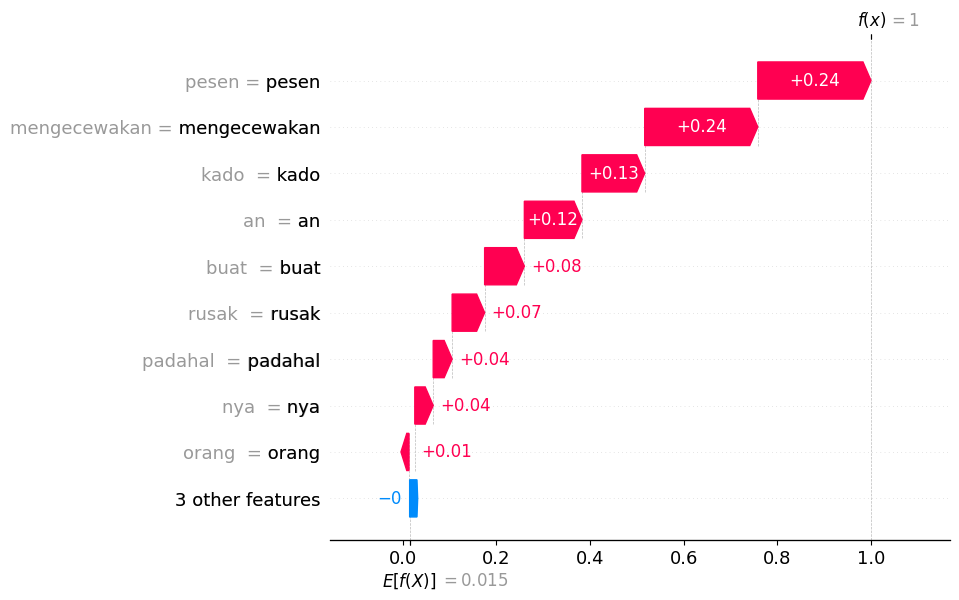


Sample 13: True=sadness, Pred=sadness


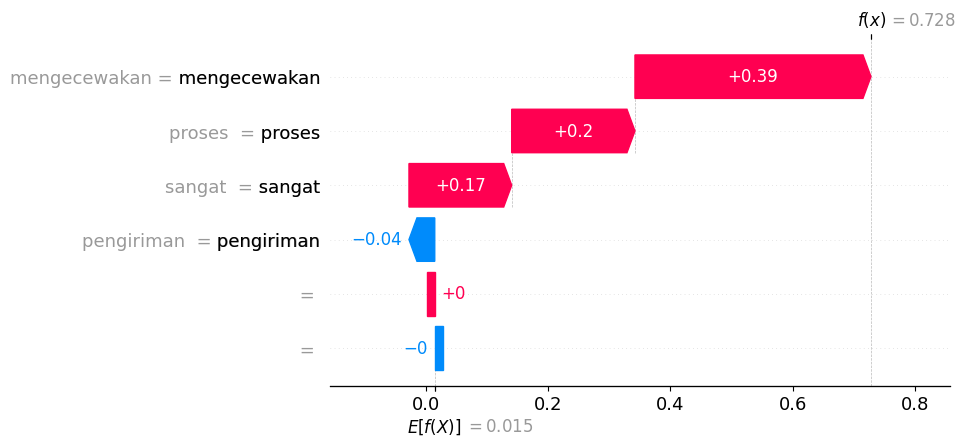


Sample 14: True=sadness, Pred=love


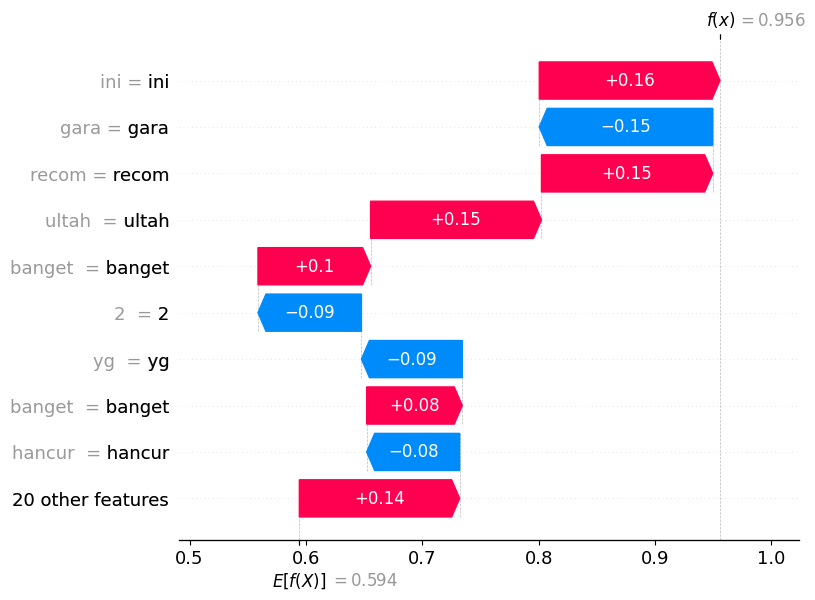

In [7]:
## 6. SHAP Explanations
# Gunakan tokenizer asli BERT sebagai masker (jauh lebih stabil daripada regex)
masker = shap.maskers.Text(tokenizer)
explainer_shap = shap.Explainer(predict_proba, masker, output_names=CLASS_NAMES)

# Gunakan batch_size untuk efisiensi memori
shap_values = explainer_shap(samples['review_clean'].tolist(), batch_size=16)

for i in range(len(samples)):
    probs = predict_proba([samples.iloc[i]['review_clean']])[0]
    pred_idx = int(np.argmax(probs))
    print(f"\nSample {i}: True={samples.iloc[i]['emotion_label']}, Pred={CLASS_NAMES[pred_idx]}")
    # Gunakan text plot jika waterfall gagal pada token BERT
    shap.plots.waterfall(shap_values[i, :, pred_idx])

In [8]:
## 10. Quantitative Faithfulness Metrics
from scipy.stats import spearmanr

def get_top_k_features(explanation, k=5, mode='lime'):
    if mode == 'lime':
        # explanation adalah objek LIME
        # Ambil label prediksi teratas
        label = list(explanation.local_exp.keys())[0]
        # Ambil top k fitur positif
        features = [x[0] for x in explanation.local_exp[label] if x[1] > 0][:k]
        return set(features)
    else:
        # explanation adalah array shap_values untuk satu sampel
        # Ambil top k indeks fitur dengan nilai tertinggi
        top_indices = np.argsort(explanation)[-k:]
        return set(top_indices)

metrics_results = []
print("Calculating Faithfulness Metrics for 15 samples...")

for i in range(len(samples)):
    text = str(samples.iloc[i]['review_clean'])
    probs = predict_proba([text])[0]
    pred_idx = int(np.argmax(probs))
    
    # 1. LIME Top Features
    exp_lime = explainer_lime.explain_instance(text, predict_proba, num_features=20, labels=[pred_idx])
    lime_feats = dict(exp_lime.as_list(label=pred_idx))
    
    # 2. SHAP Top Features (mengambil dari hasil yang sudah dihitung sebelumnya)
    # shap_values[i, :, pred_idx]
    shap_vals_sample = shap_values[i, :, pred_idx].values
    feature_names = shap_values[i, :, pred_idx].feature_names
    shap_feats = dict(zip(feature_names, shap_vals_sample))
    
    # Ambil Top 5 kata kunci (yang positif saja)
    top_lime = sorted([k for k,v in lime_feats.items() if v > 0], key=lambda x: lime_feats[x], reverse=True)[:5]
    top_shap = sorted([k for k,v in shap_feats.items() if v > 0], key=lambda x: shap_feats[x], reverse=True)[:5]
    
    # 3. Jaccard Similarity
    set_lime, set_shap = set(top_lime), set(top_shap)
    jaccard = len(set_lime & set_shap) / len(set_lime | set_shap) if len(set_lime | set_shap) > 0 else 0
    
    metrics_results.append({
        'Sample_ID': i,
        'True_Label': samples.iloc[i]['emotion_label'],
        'Pred_Label': CLASS_NAMES[pred_idx],
        'Jaccard_Similarity': jaccard,
        'Top_LIME': ", ".join(top_lime),
        'Top_SHAP': ", ".join(top_shap)
    })

df_metrics = pd.DataFrame(metrics_results)
df_metrics.to_csv(MODEL_DIR / 'faithfulness_metrics.csv', index=False)
print(f"\nAverage Jaccard Similarity: {df_metrics['Jaccard_Similarity'].mean():.4f}")
display(df_metrics[['Sample_ID', 'True_Label', 'Pred_Label', 'Jaccard_Similarity']])

Calculating Faithfulness Metrics for 15 samples...

Average Jaccard Similarity: 0.5219


,Sample_ID,True_Label,Pred_Label,Jaccard_Similarity
0,0,happy,happy,0.500000
1,1,happy,happy,1.000000
2,2,happy,love,0.250000
3,3,love,love,0.428571
4,4,love,love,0.600000
5,5,love,happy,0.800000
6,6,anger,anger,1.000000
7,7,anger,anger,0.666667
8,8,anger,fear,0.333333
9,9,fear,fear,0.111111
